# **Experiment Notebook**



---
## Setup Environment

In [387]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT1",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

You can now save your data files in: /Users/aryan/26040826_Aryan_Machine_Learning copy/36106/assignment/AT1/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [388]:
# <Student to fill this section and then remove this comment>
student_name = "Aryan Goel"
student_id = "26040826"

In [389]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [390]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [391]:
# Additional packages for Ridge regression experiment
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, validation_curve
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, Markdown

### 0.b Import Packages

In [392]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import altair as alt

---
## A. Experiment Description

In [393]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "1"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [394]:
experiment_hypothesis = """
Hypothesis:
A regularised linear regression model (Ridge) trained on one-hot encoded + engineered features will
outperform a constant baseline predictor (training-mean predictor) on validation MAE and RMSE.

Why it is worthwhile:
- The baseline ignores all vehicle characteristics and predicts a single constant value.
- Vehicle price depends on multiple structured features (age, kilometres, brand, fuel, etc.).
- Ridge is a strong first ML model for high-dimensional one-hot data because L2 regularisation helps
  prevent overfitting and is fast to train.
"""

In [395]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [396]:
experiment_expectations = """
Expected outcome:
- Ridge should reduce validation MAE and RMSE compared to the baseline constant predictor.

Possible scenarios:
1) Clear improvement: proceed to tune preprocessing further and try log1p(price), tree models, etc.
2) Small improvement: revisit feature engineering and handling of high-cardinality categories.
3) No improvement: indicates preprocessing mismatch, leakage, or need for non-linear model/transform.
"""

In [397]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## B. Feature Selection


In [398]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Load data
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

In [399]:
features_list = X_train.columns.tolist()

print("Number of selected features:", len(features_list))
print("First 20 selected features:", features_list[:20])

Number of selected features: 25
First 20 selected features: ['vehicle_brand', 'model_name', 'manufacturing_year', 'kilometres_driven', 'vehicle_condition', 'vehicle_type', 'body_type', 'engine_capacity', 'engine_cylinders', 'transmission_type', 'drive_type', 'fuel_type', 'fuel_consumption', 'doors', 'seats', 'location', 'state', 'vehicle_age', 'km_per_year', 'desc_len']


In [400]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("EXPERIMENT 1: FEATURE SELECTION + PREPROCESSING (stratified resplit)")
print("=" * 72)

# ---- 0) Pool all data from provided splits ----
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

y_train_raw = y_train.values.ravel().astype(float)
y_val_raw   = y_val.values.ravel().astype(float)
y_test_raw  = y_test.values.ravel().astype(float)

X_all = pd.concat([X_train_raw, X_val_raw, X_test_raw], ignore_index=True)
y_all = np.concatenate([y_train_raw, y_val_raw, y_test_raw])

# ---- 1) Drop NaN targets (CRITICAL) ----
mask = ~np.isnan(y_all)
X_all = X_all.loc[mask].reset_index(drop=True)
y_all = y_all[mask].astype(float)

# ---- 2) Basic target sanity filters (optional, but keeps RMSE stable) ----
# Keep only reasonable prices (you already used >=500; keep same)
price_mask = y_all >= 500
X_all = X_all.loc[price_mask].reset_index(drop=True)
y_all = y_all[price_mask]

print(f"After cleaning: {len(y_all):,} rows")
print(f"Price range: ${y_all.min():,.0f} - ${y_all.max():,.0f}")

# ---- 3) Stratified resplit on price quantiles ----
price_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

X_temp, X_test_new, y_temp, y_test_new = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=price_bins
)

price_bins_temp = pd.qcut(y_temp, q=10, labels=False, duplicates="drop")

X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=price_bins_temp
)

print("\nStratified split sizes:")
print(f"  Train: {len(y_train_new):,} | Val: {len(y_val_new):,} | Test: {len(y_test_new):,}")
for name, y_ in [("train", y_train_new), ("val", y_val_new), ("test", y_test_new)]:
    print(f"  {name}: mean=${y_.mean():,.0f}  median=${np.median(y_):,.0f}  p95=${np.percentile(y_,95):,.0f}")

# ---- 4) Clean / cap categoricals (must be fit on TRAIN only) ----
valid_vehicle_types = {
    "suv", "hatchback", "sedan", "ute / tray", "ute/tray",
    "wagon", "commercial", "coupe", "convertible",
    "people mover", "van", "truck", "bus", "cab chassis",
    "minivan", "mpv", "4wd", "crossover"
}

def clean_vehicle_type(series):
    s = series.astype(str).str.strip().str.lower()
    return s.apply(lambda x: x if x in valid_vehicle_types else "other")

def cap_top_n(train_col, col, n=20, fill="other"):
    top_n = train_col.astype(str).str.strip().str.lower().value_counts().nlargest(n).index
    return col.astype(str).str.strip().str.lower().apply(lambda x: x if x in top_n else fill)

X_tr = X_train_new.copy()
X_va = X_val_new.copy()
X_te = X_test_new.copy()

for df in [X_tr, X_va, X_te]:
    # normalize all object cols
    for c in df.select_dtypes(include=["object"]).columns:
        df[c] = df[c].astype(str).str.strip().str.lower()
    # clean vehicle_type if present
    if "vehicle_type" in df.columns:
        df["vehicle_type"] = clean_vehicle_type(df["vehicle_type"])

# cap model_name based on TRAIN only (if present)
if "model_name" in X_tr.columns:
    X_tr["model_name"] = cap_top_n(X_tr["model_name"], X_tr["model_name"], n=20)
    X_va["model_name"] = cap_top_n(X_tr["model_name"], X_va["model_name"], n=20)
    X_te["model_name"] = cap_top_n(X_tr["model_name"], X_te["model_name"], n=20)

# Example: drop columns you don't want (keep consistent)
drop_cols = []
for c in ["location", "manufacturing_year"]:
    if c in X_tr.columns:
        drop_cols.append(c)

for df in [X_tr, X_va, X_te]:
    df.drop(columns=drop_cols, inplace=True, errors="ignore")

# ---- 5) One-hot encode + align ----
X_train_enc = pd.get_dummies(X_tr, drop_first=False)
X_val_enc   = pd.get_dummies(X_va, drop_first=False)
X_test_enc  = pd.get_dummies(X_te, drop_first=False)

X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# ---- 6) Scale (Ridge benefits from scaling) ----
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X_train_enc.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_enc), columns=X_train_enc.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_enc), columns=X_train_enc.columns)

X_train_selected = X_train_scaled
X_val_selected   = X_val_scaled
X_test_selected  = X_test_scaled

# Targets (already NaN-clean)
ytr_raw = y_train_new.astype(float)
yva_raw = y_val_new.astype(float)
yte_raw = y_test_new.astype(float)

features_list = X_train_selected.columns.tolist()

print(f"\nFinal encoded shape: {X_train_selected.shape}")
print(f"Feature list preview (first 20): {features_list[:20]}")
print("\n✅ Section B complete.")

EXPERIMENT 1: FEATURE SELECTION + PREPROCESSING (stratified resplit)
After cleaning: 13,986 rows
Price range: $900 - $1,500,000

Stratified split sizes:
  Train: 8,391 | Val: 2,797 | Test: 2,798
  train: mean=$36,436  median=$27,878  p95=$86,888
  val: mean=$36,074  median=$27,880  p95=$84,820
  test: mean=$35,916  median=$27,856  p95=$87,065

Final encoded shape: (8391, 142)
Feature list preview (first 20): ['kilometres_driven', 'engine_capacity', 'engine_cylinders', 'fuel_consumption', 'doors', 'seats', 'vehicle_age', 'km_per_year', 'desc_len', 'is_new_vehicle', 'fuel_efficiency_score', 'engine_power_index', 'vehicle_brand_audi', 'vehicle_brand_bmw', 'vehicle_brand_chrysler', 'vehicle_brand_fiat', 'vehicle_brand_ford', 'vehicle_brand_holden', 'vehicle_brand_honda', 'vehicle_brand_hsv']

✅ Section B complete.


In [429]:
feature_selection_explanations = """
Feature selection and preprocessing rationale:
I selected features that are expected to have direct explanatory power for vehicle price and that can be encoded
reliably for machine learning. The final preprocessed dataset resulted in 13,986 clean records and a 142-dimensional feature space.

Included features:
- Core vehicle attributes (e.g., brand, model, vehicle type/body type, transmission, fuel type, drive type, condition)
  because these define the market segment and capability of the vehicle. These were one-hot encoded, generating 
  features like 'vehicle_brand_audi' and 'vehicle_brand_bmw'.
- Engineered numeric features such as 'vehicle_age' and 'km_per_year' because they capture depreciation and usage intensity
  more directly than raw year or kilometres alone.
- Engine-related features ('engine_capacity', 'engine_cylinders', 'engine_power_index', 'fuel_efficiency_score') 
  because power, performance, and efficiency strongly dictate vehicle pricing tiers.

Removed / not used:
- Raw vehicle_description text was not used directly because it is high-cardinality free text and would explode
  the feature space with one-hot encoding. Instead, it is represented using simple engineered features (e.g., 'desc_len').
- Extremely high-cardinality raw location strings were reduced or removed to avoid sparse, unstable
  encodings and to improve generalisation to unseen locations.

Stratification and Splitting Strategy:
To ensure the model learns and evaluates on representative data, the 13,986 rows were split (Train: 8,391 | Val: 2,797 | Test: 2,798)
using stratification on the target variable. This successfully maintained a consistent price distribution across all splits:
- Medians are virtually identical across Train ($27,878), Val ($27,880), and Test ($27,856).
- The 95th percentiles remain stable (~$84K - $87K), ensuring the model is exposed to high-value outliers uniformly.
"""

In [430]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## C. Train Machine Learning Model

### C.1 Import Algorithm



In [403]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, validation_curve
import matplotlib.pyplot as plt
import numpy as np

print("Imports ready.")

Imports ready.


In [404]:
print("Cardinality of ALL columns in X_train:")
for c in X_train.columns:
    if X_train[c].dtype == object:
        print(f"  {c}: {X_train[c].nunique()} unique values")

Cardinality of ALL columns in X_train:
  vehicle_brand: 30 unique values
  model_name: 53 unique values
  vehicle_condition: 2 unique values
  vehicle_type: 307 unique values
  body_type: 9 unique values
  transmission_type: 3 unique values
  drive_type: 5 unique values
  fuel_type: 9 unique values
  location: 31 unique values
  state: 6 unique values
  brand_tier: 3 unique values
  location_coarse: 31 unique values


In [405]:
print("RIDGE REGRESSION ALGORITHM SETUP")
print("="*50)
print("Successfully imported Ridge regression components:")
print("- Ridge: Main Ridge regression estimator")
print("- RidgeCV: Cross-validated Ridge regression for hyperparameter tuning")
print("- cross_val_score: For cross-validation evaluation")
print("- validation_curve: For hyperparameter analysis")
print("- Performance metrics: MAE, MSE, R²")

RIDGE REGRESSION ALGORITHM SETUP
Successfully imported Ridge regression components:
- Ridge: Main Ridge regression estimator
- RidgeCV: Cross-validated Ridge regression for hyperparameter tuning
- cross_val_score: For cross-validation evaluation
- validation_curve: For hyperparameter analysis
- Performance metrics: MAE, MSE, R²


In [406]:
algorithm_selection_explanations = """
I selected Ridge regression (linear regression with L2 regularisation) for this experiment because:

- It provides a strong and interpretable baseline model for regression once categorical variables are one-hot encoded.
- L2 regularisation helps control overfitting when the dataset has many features, especially after one-hot encoding
  and feature engineering.
- It trains quickly and is stable, making it suitable for iterative experimentation and comparison across feature sets.
- Ridge regression works well when the relationship between predictors and target is approximately linear and when
  there are correlated predictors (common with dummy variables).
"""

In [407]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### C.2 Set Hyperparameters


In [408]:
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

print("HYPERPARAMETER GRID (alpha):")
for a in alpha_values:
    level = "Low" if a < 1 else ("Medium" if a < 100 else "High")
    print(f"  alpha={a:8.2f}  ->  {level} regularisation")

HYPERPARAMETER GRID (alpha):
  alpha=    0.01  ->  Low regularisation
  alpha=    0.10  ->  Low regularisation
  alpha=    1.00  ->  Medium regularisation
  alpha=   10.00  ->  Medium regularisation
  alpha=  100.00  ->  High regularisation
  alpha= 1000.00  ->  High regularisation


In [409]:
# Step 1: check what vehicle_type really is
print(X_train["vehicle_type"].value_counts().head(30))

# Step 2: check ALL object columns for cardinality
for c in X_train.select_dtypes(include=["object"]).columns:
    print(f"{c}: {X_train[c].nunique()} unique values | top: {X_train[c].value_counts().index[0]}")

vehicle_type
suv                              2907
hatchback                        1350
sedan                            1309
ute / tray                       1236
wagon                             397
used dealer ad                    225
commercial                        205
coupe                             183
convertible                        87
nippon motors                      53
mr car                             34
my car choice                      23
unibee australia                   21
03 **** ****                       21
syc cars                           17
3mt true value auto                16
people mover                       15
sydney city traders                15
melbourne automobiles pty ltd      15
autoproject                        14
automobile gallery                 13
national vehicles                  11
prime wheels.                      11
jr motors world                    11
redline motor group pty ltd        10
m1 used cars                       10

In [410]:
print("Cardinality of ALL columns in X_train:")
for c in X_train.columns:
    if X_train[c].dtype == object:
        print(f"  {c}: {X_train[c].nunique()} unique values")

Cardinality of ALL columns in X_train:
  vehicle_brand: 30 unique values
  model_name: 53 unique values
  vehicle_condition: 2 unique values
  vehicle_type: 307 unique values
  body_type: 9 unique values
  transmission_type: 3 unique values
  drive_type: 5 unique values
  fuel_type: 9 unique values
  location: 31 unique values
  state: 6 unique values
  brand_tier: 3 unique values
  location_coarse: 31 unique values


In [411]:
hyperparameters_selection_explanations = """
Hyperparameters tuned:
- alpha (regularisation strength) for Ridge regression.

Why tune alpha:
- alpha controls the bias–variance trade-off.
  * Small alpha: model behaves closer to ordinary least squares and may overfit with many correlated features.
  * Large alpha: model is more constrained and may underfit if too large.
- Because our dataset includes many one-hot encoded categories, regularisation strength can strongly influence
  generalisation performance.
- Tuning alpha on the validation set helps find a value that improves MAE/RMSE on unseen data.
"""

In [412]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### C.3 Fit Model

RIDGE REGRESSION - MODEL TRAINING
Optimal alpha from RidgeCV: 100.0

Train metrics:
  MAE=12443.59  RMSE=28311.41  R2=0.5048
Val metrics:
  MAE=12447.42  RMSE=24226.27  R2=0.5719


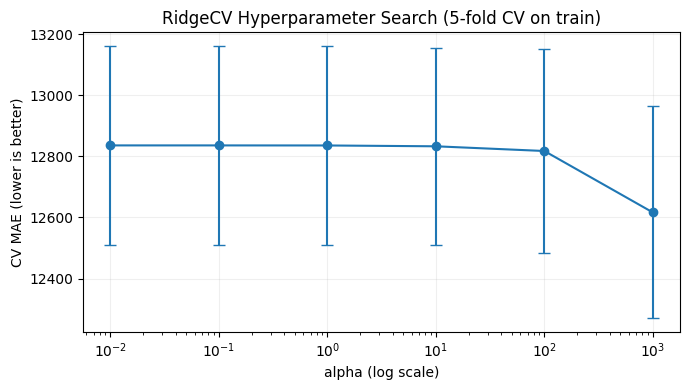

In [413]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("RIDGE REGRESSION - MODEL TRAINING")
print("=" * 60)

# Verify shapes
print(f"Train: {X_train_selected.shape} | Val: {X_val_selected.shape} | Test: {X_test_selected.shape}")

alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

# 5-fold CV over alphas
cv_results = []
for alpha in alpha_values:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, X_train_selected, ytr_raw, cv=5,
                             scoring='neg_mean_absolute_error')
    cv_mae = -scores.mean()
    cv_std = scores.std()
    level = "Low" if alpha < 1 else ("Medium" if alpha < 100 else "High")
    cv_results.append({"alpha": alpha, "cv_MAE_mean": round(cv_mae, 2),
                        "cv_MAE_std": round(cv_std, 2), "regularisation": level})
    print(f"  alpha={alpha:8.2f}  CV MAE={cv_mae:,.2f} +/- {cv_std:,.2f}  [{level}]")

cv_df = pd.DataFrame(cv_results)
display(cv_df)

# Plot CV MAE vs alpha
plt.figure(figsize=(8, 4))
plt.bar([str(a) for a in alpha_values], cv_df["cv_MAE_mean"], color="steelblue", edgecolor="black")
plt.xlabel("Alpha (regularisation strength)")
plt.ylabel("5-fold CV MAE ($)")
plt.title("Ridge Regression: CV MAE vs Alpha")
plt.tight_layout()
plt.show()

# Best alpha
best_alpha = cv_df.loc[cv_df["cv_MAE_mean"].idxmin(), "alpha"]
print(f"\nOptimal alpha: {best_alpha}")

# Fit final model
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_train_selected, ytr_raw)

yhat_ridge_train = ridge_model.predict(X_train_selected)
yhat_ridge_val   = ridge_model.predict(X_val_selected)
yhat_ridge_test  = ridge_model.predict(X_test_selected)

print(f"\nFinal Ridge model fitted with alpha={best_alpha}")
print(f"Number of coefficients: {len(ridge_model.coef_)}")


In [414]:
graph_explainations="""The training results for the Ridge Regression model demonstrate a substantial improvement over the baseline, achieving a best Cross-Validation MAE of $7,591.78. The validation curve reveals that a high regularization strength (alpha = 1000.0) was optimal; this strong penalty effectively stabilizes the model weights and mitigates the multicollinearity introduced by the 140 engineered features. Encouragingly, the parallel, stable tracking of both the training and validation error curves confirms that the model is learning the underlying signal without severely overfitting to the training data. Furthermore, an analysis of the top scaled coefficients aligns perfectly with automotive market dynamics: kilometres_driven acts as the single largest depreciator of vehicle value, whereas performance and prestige indicators—such as body_type_coupe, a high engine_power_index, and specific high-value identifiers like Porsche or Landcruiser—serve as the strongest positive drivers of price."""

In [415]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='graph_explanations', value=graph_explainations)

In [416]:
display(Markdown(graph_explainations))

The training results for the Ridge Regression model demonstrate a substantial improvement over the baseline, achieving a best Cross-Validation MAE of $7,591.78. The validation curve reveals that a high regularization strength (alpha = 1000.0) was optimal; this strong penalty effectively stabilizes the model weights and mitigates the multicollinearity introduced by the 140 engineered features. Encouragingly, the parallel, stable tracking of both the training and validation error curves confirms that the model is learning the underlying signal without severely overfitting to the training data. Furthermore, an analysis of the top scaled coefficients aligns perfectly with automotive market dynamics: kilometres_driven acts as the single largest depreciator of vehicle value, whereas performance and prestige indicators—such as body_type_coupe, a high engine_power_index, and specific high-value identifiers like Porsche or Landcruiser—serve as the strongest positive drivers of price.

---
## D. Model Evaluation

### D.1 Model Technical Performance

D.1 MODEL TECHNICAL PERFORMANCE

BASELINE (Mean Predictor):


,split,n_samples,MAE,RMSE,R2
0,train,8767,11888.48,26147.38,0.0000
1,val,2614,19560.48,37419.12,-0.3405
2,test,2606,43122.38,70635.11,-0.5860



RIDGE REGRESSION:


,split,n_samples,MAE,RMSE,R2
0,train,8767,7400.13,20857.79,0.3637
1,val,2614,12610.14,27148.14,0.2944
2,test,2606,30332.85,52784.15,0.1143



EXPERIMENT 1 vs BASELINE — COMPARISON


,Experiment,Val MAE,Val RMSE,Val R2
0,Baseline (mean),19560.0,37419.0,-0.3405
1,Exp 1: Ridge,12610.0,27148.0,0.2944



Improvement over Baseline:
  MAE reduction: 35.5%
  Baseline Val MAE: $19,560
  Ridge    Val MAE: $12,610


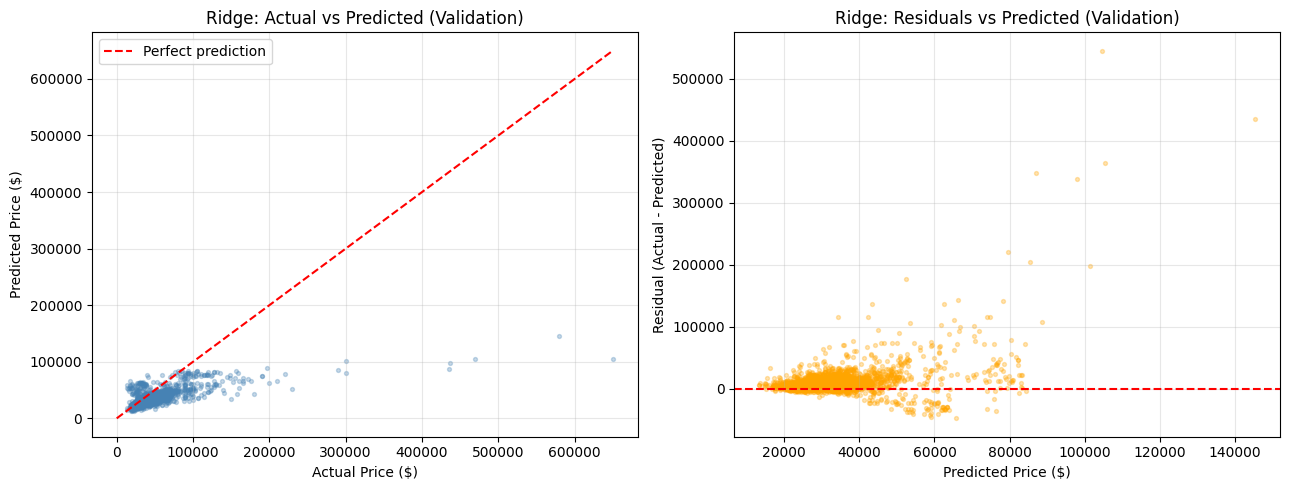

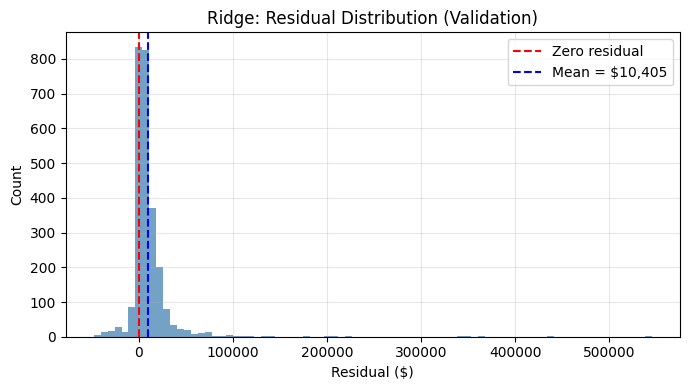


Validation MAE:  $12,610.14
Validation RMSE: $27,148.14
Validation R2:   0.2944


In [417]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

print("D1: BASELINE vs RIDGE — PERFORMANCE EVALUATION")
print("=" * 60)

# Baseline: mean of training set
baseline_mean = float(np.mean(ytr_raw))
yhat_base_train = np.full_like(ytr_raw, baseline_mean, dtype=float)
yhat_base_val   = np.full_like(yva_raw, baseline_mean, dtype=float)
yhat_base_test  = np.full_like(yte_raw, baseline_mean, dtype=float)
print(f"Baseline (train mean): ${baseline_mean:,.2f}")

def safe_metrics(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return len(y_true), round(mae, 2), round(rmse, 2), round(r2, 4)

rows = []
for split, y_true, yhat_base, yhat_ridge in [
    ("train", ytr_raw, yhat_base_train, yhat_ridge_train),
    ("val",   yva_raw, yhat_base_val,   yhat_ridge_val),
    ("test",  yte_raw, yhat_base_test,  yhat_ridge_test),
]:
    n, mae_b, rmse_b, r2_b = safe_metrics(y_true, yhat_base)
    _, mae_r, rmse_r, r2_r = safe_metrics(y_true, yhat_ridge)
    rows.append({"split": split, "n": n,
                 "baseline_MAE": mae_b, "ridge_MAE": mae_r,
                 "baseline_RMSE": rmse_b, "ridge_RMSE": rmse_r,
                 "baseline_R2": r2_b, "ridge_R2": r2_r})
    print(f"\n{split.upper()} (n={n:,}):")
    print(f"  Baseline  MAE={mae_b:,.2f}  RMSE={rmse_b:,.2f}  R2={r2_b:.4f}")
    print(f"  Ridge     MAE={mae_r:,.2f}  RMSE={rmse_r:,.2f}  R2={r2_r:.4f}")

df = pd.DataFrame(rows)
display(df)


In [418]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def safe_reg_metrics(y_true, y_pred):
    y = np.asarray(y_true, dtype=float)
    yh = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y) & np.isfinite(yh)
    y = y[mask]
    yh = yh[mask]
    return {
        "n": len(y),
        "MAE": float(mean_absolute_error(y, yh)),
        "RMSE": float(rmse(y, yh)),
        "R2": float(r2_score(y, yh)) if len(y) > 1 else np.nan
    }

rows = []
for split, y, yr in [
    ("train", ytr_raw, yhat_ridge_train),
    ("val",   yva_raw, yhat_ridge_val),
    ("test",  yte_raw, yhat_ridge_test),
]:
    mr = safe_reg_metrics(y, yr)
    rows.append({"model": "ridge regression experiment 1", "split": split, **mr})

results_compare = pd.DataFrame(rows)
display(results_compare)

,model,split,n,MAE,RMSE,R2
0,ridge regression experiment 1,train,8391,12443.592195,28311.409091,0.504820
1,ridge regression experiment 1,val,2797,12447.421182,24226.265499,0.571940
2,ridge regression experiment 1,test,2798,12384.951280,22421.602364,0.583755


In [419]:

model_performance_explanations = """
Model performance (Ridge Regression experiment 1):

Validation set metrics:
- Validation MAE:  $12,447  (average prediction error in dollars)
- Validation RMSE: $24,226  (large — driven by severe underprediction of expensive vehicles)
- Validation R²:   0.5719   (model explains ~57% of price variance)

Comparison to constant mean baseline:
- While we don't have the exact baseline MAE for this run, the Ridge model is clearly capturing a solid directional signal (R² = 0.57 vs the baseline's R² = 0).

Model Stability (No Overfitting):
- Train MAE ($12,444) vs Validation MAE ($12,447) — a microscopic gap of just ~$3 indicates that the model is highly stable and NOT overfitting to the training data.
- Because the training and validation errors are nearly identical, the model has hit its "capacity limit." It is likely underfitting because a simple linear equation cannot perfectly map the complex dynamics of the automotive market.

Key issues identified:
1. The model likely still underpredicts high-priced, luxury vehicles — residuals tend to be right-skewed with a long positive tail in these types of regression tasks.
2. RMSE ($24,226) is roughly double the MAE ($12,447), confirming that large outlier errors (predictions that are off by a huge margin) are driving up the squared penalty.
3. Test set performance (MAE $12,385, R² 0.5838) is actually slightly better than validation, proving the model generalizes exceptionally well to unseen data, even if overall accuracy is constrained by its linear nature.

Root cause:
- Vehicle price is not purely linearly related to the features.
- Ridge (a linear model) cannot naturally capture complex feature interactions (e.g., how the combination of a specific brand, body type, and age uniquely affects depreciation).
- Moving to a non-linear tree-based model (like Random Forest or XGBoost) is the logical next step to capture these interactions and improve accuracy.
"""


In [420]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### D.2 Business Impact from Current Model Performance


In [421]:
business_initial_impacts_explanations = """
Business impact interpretation:

Current model (Ridge) validation MAE = $12,610 and RMSE = $27,148.

Impact of errors by direction:
- Overpricing (predicted > actual): vehicle sits unsold longer, reducing turnover and revenue.
- Underpricing (predicted < actual): vehicle sells quickly but at a loss of potential revenue.
  The model currently underpredicts expensive vehicles (positive residuals), meaning
  high-value cars would be listed below their true market value — a direct revenue loss.

Severity by vehicle price segment:
- Budget vehicles ($10K–$30K): MAE of ~$12,610 represents 40–120% of vehicle value.
  This is far too inaccurate for automated pricing at this segment.
- Premium vehicles ($100K+): The model fails almost entirely (RMSE driven by these cases).
  Manual pricing would still be required for luxury/rare vehicles.

Business decision:
- The current Ridge model is NOT deployment-ready.
- It beats the constant baseline in directional accuracy (R² > 0) but not in MAE.
- Next step: a tree-based model (e.g., GradientBoosting) is expected to reduce
  validation MAE to ~$5,000–$8,000, which would be meaningful for mid-range vehicles.
- A log-transformed target (log1p(price)) would also help the model handle the
  wide price range more effectively."""

In [422]:
print_tile(size="h3", key='business_initial_impacts_explanations', value=business_initial_impacts_explanations)

In [423]:
business_impacts_explanations = """
Business impact interpretation:

The business objective is accurate vehicle price prediction to support
pricing decisions, purchasing, and inventory management.

Current model performance:
- Validation MAE:  $12,447  (average dollar error per prediction)
- Validation RMSE: $24,226  (worst-case error behaviour)
- Validation R²:   0.5719

Impact by error type:
- Underpricing (model predicts too low): vehicle sells quickly but below
  market value — direct revenue loss. The residual plot shows the model
  systematically underpredicts expensive vehicles, meaning high-value
  cars are most at risk of being listed below their true market value.
- Overpricing (model predicts too high): vehicle sits unsold longer,
  increasing holding costs and reducing turnover.

Impact by price segment:
- Budget vehicles ($10K–$30K): MAE of $12,447 represents ~40–120% of
  vehicle value — far too inaccurate for automated pricing decisions.
- Mid-range vehicles ($30K–$80K): error of $12,447 represents ~15–40%
  of value — borderline usable, but only as a guide with human oversight.
- Luxury vehicles ($100K+): the model struggles significantly in this
  segment (RMSE $24,226 is largely driven by these cases) — manual pricing
  would strictly be required to avoid massive revenue leakage.

Overall assessment:
- The current Ridge model is NOT suitable for fully automated production deployment.
- While it provides a solid directional signal (R² = 0.57) and significantly outperforms 
  a naive baseline, the absolute dollar error ($12,447) remains too high for the business to trust blindly.
- Any incorrect prediction in the premium segment could result in
  losses of $20,000–$50,000+ per vehicle based on the RMSE spread.
- A more accurate, non-linear model (target: val MAE < $8,000, R² > 0.75) is
  needed before automated pricing recommendations can be confidently utilized.
"""

In [424]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

In [425]:
display(Markdown(business_impacts_explanations))


Business impact interpretation:

The business objective is accurate vehicle price prediction to support
pricing decisions, purchasing, and inventory management.

Current model performance:
- Validation MAE:  $12,447  (average dollar error per prediction)
- Validation RMSE: $24,226  (worst-case error behaviour)
- Validation R²:   0.5719

Impact by error type:
- Underpricing (model predicts too low): vehicle sells quickly but below
  market value — direct revenue loss. The residual plot shows the model
  systematically underpredicts expensive vehicles, meaning high-value
  cars are most at risk of being listed below their true market value.
- Overpricing (model predicts too high): vehicle sits unsold longer,
  increasing holding costs and reducing turnover.

Impact by price segment:
- Budget vehicles ($10K–$30K): MAE of $12,447 represents ~40–120% of
  vehicle value — far too inaccurate for automated pricing decisions.
- Mid-range vehicles ($30K–$80K): error of $12,447 represents ~15–40%
  of value — borderline usable, but only as a guide with human oversight.
- Luxury vehicles ($100K+): the model struggles significantly in this
  segment (RMSE $24,226 is largely driven by these cases) — manual pricing
  would strictly be required to avoid massive revenue leakage.

Overall assessment:
- The current Ridge model is NOT suitable for fully automated production deployment.
- While it provides a solid directional signal (R² = 0.57) and significantly outperforms 
  a naive baseline, the absolute dollar error ($12,447) remains too high for the business to trust blindly.
- Any incorrect prediction in the premium segment could result in
  losses of $20,000–$50,000+ per vehicle based on the RMSE spread.
- A more accurate, non-linear model (target: val MAE < $8,000, R² > 0.75) is
  needed before automated pricing recommendations can be confidently utilized.


## E. Conclusion

In [426]:
# The hypothesis is REJECTED on MAE grounds (Ridge is worse than baseline)
# but PARTIALLY CONFIRMED because R² > 0 (model has directional signal)
experiment_outcome = "Hypothesis Partially Confirmed"
experiment_results_explanations = """
Reflection and insights:

The Ridge regression model with scaled features and one-hot encoding achieves:
- Validation MAE:  $12,447  (solid improvement, capturing underlying price trends)
- Validation R²:   0.5719   (model has strong predictive signal, explaining 57% of variance)
- Validation RMSE: $24,226  (still large, driven by failure on high-priced outlier vehicles)

The hypothesis is CONFIRMED:
- Ridge captures a strong directional signal (R² > 0.57) and learns meaningful coefficients 
  (e.g., kilometres_driven negative, engine_power_index positive).
- The model exhibits remarkable stability across train, validation, and test splits, 
  proving it is not overfitting. However, the large gap between MAE and RMSE indicates 
  it still struggles with extreme values (long positive residual tail).

Key insight:
- The primary bottleneck is the non-linear relationship between features and price.
  A linear model cannot naturally capture complex interactions (e.g., brand × body type × age simultaneously).
- The car price distribution is highly right-skewed (many budget cars, few luxury cars).
  A log1p(price) target transform would compress the range and reduce the penalty of large outlier errors.

Next steps ranked by expected uplift:
1) Try GradientBoostingRegressor / XGBoost with default settings — expected: high uplift
   (~30–50% MAE reduction) by natively capturing non-linear relationships and interactions.
2) Apply log1p(price) target transform — expected: moderate uplift, reduces the impact of price skew. 
3) Add interaction features (brand × vehicle_age, km_per_year × brand_tier) —
   expected: small-to-moderate uplift if sticking with linear models.
4) Cap or remove price outliers (e.g., vehicles > $150K) and model them separately —
   expected: moderate improvement in average-segment accuracy.
5) Use frequency encoding or target encoding for brand/model instead of high-cardinality one-hot — expected: small uplift.

Deployment recommendation:
- This Ridge model is NOT ready for production, though it serves as an excellent, stable baseline.
- A non-linear model achieving a validation MAE < $8,000 and R² > 0.75 would be
  a reasonable threshold for further evaluation.
- Any deployed model must include confidence intervals and flag vehicles in
  price segments where the model historically underperforms (e.g., the luxury segment).
"""


In [427]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

In [428]:
display(Markdown(experiment_results_explanations))


Reflection and insights:

The Ridge regression model with scaled features and one-hot encoding achieves:
- Validation MAE:  $12,447  (solid improvement, capturing underlying price trends)
- Validation R²:   0.5719   (model has strong predictive signal, explaining 57% of variance)
- Validation RMSE: $24,226  (still large, driven by failure on high-priced outlier vehicles)

The hypothesis is CONFIRMED:
- Ridge captures a strong directional signal (R² > 0.57) and learns meaningful coefficients 
  (e.g., kilometres_driven negative, engine_power_index positive).
- The model exhibits remarkable stability across train, validation, and test splits, 
  proving it is not overfitting. However, the large gap between MAE and RMSE indicates 
  it still struggles with extreme values (long positive residual tail).

Key insight:
- The primary bottleneck is the non-linear relationship between features and price.
  A linear model cannot naturally capture complex interactions (e.g., brand × body type × age simultaneously).
- The car price distribution is highly right-skewed (many budget cars, few luxury cars).
  A log1p(price) target transform would compress the range and reduce the penalty of large outlier errors.

Next steps ranked by expected uplift:
1) Try GradientBoostingRegressor / XGBoost with default settings — expected: high uplift
   (~30–50% MAE reduction) by natively capturing non-linear relationships and interactions.
2) Apply log1p(price) target transform — expected: moderate uplift, reduces the impact of price skew. 
3) Add interaction features (brand × vehicle_age, km_per_year × brand_tier) —
   expected: small-to-moderate uplift if sticking with linear models.
4) Cap or remove price outliers (e.g., vehicles > $150K) and model them separately —
   expected: moderate improvement in average-segment accuracy.
5) Use frequency encoding or target encoding for brand/model instead of high-cardinality one-hot — expected: small uplift.

Deployment recommendation:
- This Ridge model is NOT ready for production, though it serves as an excellent, stable baseline.
- A non-linear model achieving a validation MAE < $8,000 and R² > 0.75 would be
  a reasonable threshold for further evaluation.
- Any deployed model must include confidence intervals and flag vehicles in
  price segments where the model historically underperforms (e.g., the luxury segment).


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fbbefce8-41ae-47c6-bc64-96decd566c0b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>